# 02 -- HMC visual tightness + lambda sweep

## 0. Colab bootstrap (no-op locally)

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    import sys, os
    PROJECT_ROOT = '/content/drive/MyDrive/Master-thesis'
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)
    os.chdir(PROJECT_ROOT + '/notebooks')
    print('Colab setup done -- cwd:', os.getcwd())
except ImportError:
    print('Local run -- Colab bootstrap skipped')

Mounted at /content/drive
Colab setup done -- cwd: /content/drive/MyDrive/Master-thesis/notebooks


## 1. Setup

In [2]:
import json
import os
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'mnlearn').is_dir():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('could not locate project root')
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)

from mnlearn.baselines import ForwardBackwardClassifier
from mnlearn.config import load_config
from mnlearn.data import build_datasets, load_hmc_benchmark
from mnlearn.experiments import collect_results
from mnlearn.inference import viterbi_decode
from mnlearn.learning import hamming_loss, train
from mnlearn.models import build_model

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_TAG    = 'hmc_vis_tightness'
RESULTS    = REPO_ROOT / 'results' / RUN_TAG
THESIS_FIG = REPO_ROOT / 'thesis' / 'figures' / RUN_TAG
THESIS_TBL = REPO_ROOT / 'thesis' / 'tables'
THESIS_FIG.mkdir(parents=True, exist_ok=True)
THESIS_TBL.mkdir(parents=True, exist_ok=True)
print(f'DEVICE = {DEVICE}')

DEVICE = cuda


## 2. Sweep

In [3]:
SEEDS   = [0, 1, 2]
LOSSES  = ['m3n_hinge', 'lp_m3n']
LAMBDAS = [0, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

BASE_CONFIGS = {
    'm3n_hinge': load_config(REPO_ROOT / 'configs' / 'experiments' / 'm3n_hinge_hmc_visual.yaml'),
    'lp_m3n':    load_config(REPO_ROOT / 'configs' / 'experiments' / 'lpm3n_hmc_visual.yaml'),
}

def run_subname(loss, wd, seed):
    return f'{loss}_wd{wd:g}_seed{seed}'

def out_dir(loss, wd, seed):
    return RESULTS / run_subname(loss, wd, seed)

## 3. Run

In [4]:
for seed in SEEDS:
    for loss in LOSSES:
        base = BASE_CONFIGS[loss]
        for wd in LAMBDAS:
            d = out_dir(loss, wd, seed)
            if (d / 'results.json').exists():
                print(f'skip: {d.name}')
                continue
            name = f'{RUN_TAG}/{run_subname(loss, wd, seed)}'
            cfg = replace(
                base,
                experiment=replace(base.experiment, name=name, seed=seed),
                training=replace(base.training,
                                 optimizer=replace(base.training.optimizer, weight_decay=wd)),
            )
            print(f'running: {name}')
            train(cfg)

print('\ndone.')

running: hmc_vis_tightness/m3n_hinge_wd0_seed0
[run] hmc_vis_tightness/m3n_hinge_wd0_seed0  device=cuda  output=results/hmc_vis_tightness/m3n_hinge_wd0_seed0
  Epoch   1:  train_loss=3.0052  hamming=0.5453
  Epoch   3:  train_loss=0.7593  hamming=0.2883
  Epoch   6:  train_loss=0.6414  hamming=0.2686
  Epoch   9:  train_loss=0.6135  hamming=0.2610
  Epoch  12:  train_loss=0.6024  hamming=0.2555
  Epoch  15:  train_loss=0.5934  hamming=0.2536
  Epoch  18:  train_loss=0.5868  hamming=0.2521
  Epoch  21:  train_loss=0.5816  hamming=0.2523
  Epoch  24:  train_loss=0.5757  hamming=0.2477
  Epoch  27:  train_loss=0.5711  hamming=0.2508
  Epoch  30:  train_loss=0.5640  hamming=0.2525
  Epoch  33:  train_loss=0.5599  hamming=0.2510
  Epoch  36:  train_loss=0.5553  hamming=0.2502
  Epoch  39:  train_loss=0.5486  hamming=0.2513
  Epoch  42:  train_loss=0.5435  hamming=0.2511
  Epoch  45:  train_loss=0.5391  hamming=0.2542
  Epoch  48:  train_loss=0.5363  hamming=0.2525
  Epoch  51:  train_loss=0

## 4. Forward-Backward baseline

In [5]:
hmc_meta = json.loads((REPO_ROOT / 'benchmarks' / 'hmc' / 'config.json').read_text())
K       = hmc_meta['num_states']
p_self  = hmc_meta['p_self']
p_emit  = hmc_meta['p_emit']
N_TEST  = BASE_CONFIGS['m3n_hinge'].data.test_size

bench = load_hmc_benchmark(
    str(REPO_ROOT / 'benchmarks' / 'hmc'),
    mode='visual',
    mnist_root=str(REPO_ROOT / 'mnist_data'),
)
test_obs    = bench['test'].obs_indices[:N_TEST]
test_labels = bench['test'].labels[:N_TEST]

fb = ForwardBackwardClassifier(num_states=K, p_self=p_self, p_emit=p_emit)
fb_hamming = hamming_loss(fb.predict(test_obs), test_labels)
print(f'FB Bayes-optimal Hamming: {fb_hamming:.4f}')

FB Bayes-optimal Hamming: 0.2284


## 5. Aggregate

In [6]:
df = collect_results(str(RESULTS / '*_seed*/'))
df = df[df['loss'].isin(LOSSES)].copy()
cols = ['loss', 'wd', 'seed', 'hamming', 'best_epoch', 'final_epoch', 'total_seconds']
df = df[[c for c in cols if c in df.columns]].sort_values(['loss', 'wd', 'seed']).reset_index(drop=True)
df.to_csv(THESIS_TBL / 's5_2_2_lambda_sweep.csv', index=False)
df

,loss,wd,seed,hamming,best_epoch,final_epoch,total_seconds
0,lp_m3n,0.0000,0,0.251190,63,198,86.694933
1,lp_m3n,0.0000,1,0.251770,54,198,84.856068
2,lp_m3n,0.0000,2,0.254350,57,198,86.935456
3,lp_m3n,0.0001,0,0.251083,66,198,86.381393
4,lp_m3n,0.0001,1,0.251163,57,198,85.550057
5,lp_m3n,0.0001,2,0.252207,45,198,86.916576
6,lp_m3n,0.0005,0,0.248627,66,198,85.614619
7,lp_m3n,0.0005,1,0.249170,84,198,85.020696
8,lp_m3n,0.0005,2,0.249193,81,198,86.458079
9,lp_m3n,0.0010,0,0.247107,126,198,85.616493


## 6. Tightness table (best lambda per loss)

In [7]:
agg = (
    df.groupby(['loss', 'wd'])['hamming']
      .agg(['mean', 'std', 'count'])
      .reset_index()
)
best_idx = agg.groupby('loss')['mean'].idxmin()
best = agg.loc[best_idx].reset_index(drop=True)
best.loc[len(best)] = {'loss': 'FB (Bayes optimal)', 'wd': np.nan,
                        'mean': fb_hamming, 'std': 0.0, 'count': 1}
print(best.to_string(index=False))

BEST_LAMBDA = {row.loss: row.wd for row in best.itertuples() if row.loss in LOSSES}
print(f'\nBest lambda per loss: {BEST_LAMBDA}')

best.to_csv(THESIS_TBL / 's5_2_2_tightness.csv', index=False)

              loss     wd     mean      std  count
            lp_m3n 0.0050 0.246483 0.000410      3
         m3n_hinge 0.0005 0.248198 0.001027      3
FB (Bayes optimal)    NaN 0.228400 0.000000      1

Best lambda per loss: {'lp_m3n': 0.005, 'm3n_hinge': 0.0005}


## 7. Lambda sweep figure

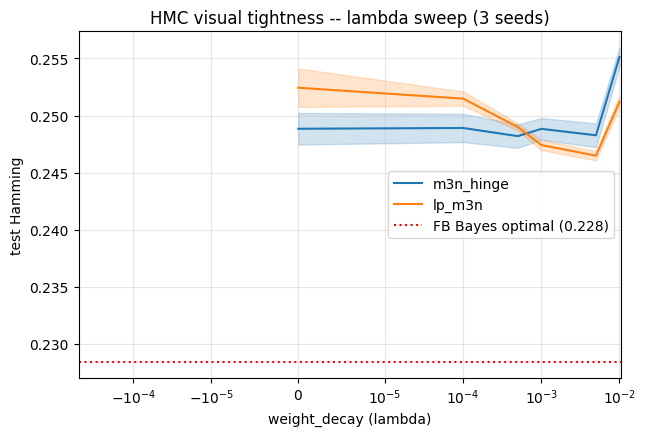

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for loss in LOSSES:
    g = (df[df['loss'] == loss].groupby('wd')['hamming']
         .agg(['mean', 'std']).reset_index().sort_values('wd'))
    line, = ax.plot(g['wd'], g['mean'], label=loss)
    ax.fill_between(g['wd'],
                    g['mean'] - g['std'].fillna(0.0),
                    g['mean'] + g['std'].fillna(0.0),
                    alpha=0.2, color=line.get_color())

ax.axhline(fb_hamming, color='red', linestyle=':',
           label=f'FB Bayes optimal ({fb_hamming:.3f})')
ax.set_xscale('symlog', linthresh=1e-5)
ax.set_xlabel('weight_decay (lambda)')
ax.set_ylabel('test Hamming')
ax.set_title(f'HMC visual tightness -- lambda sweep ({len(SEEDS)} seeds)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

fig.savefig(THESIS_FIG / 'lambda_sweep.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Per-epoch validation Hamming (best lambda, seed 0)

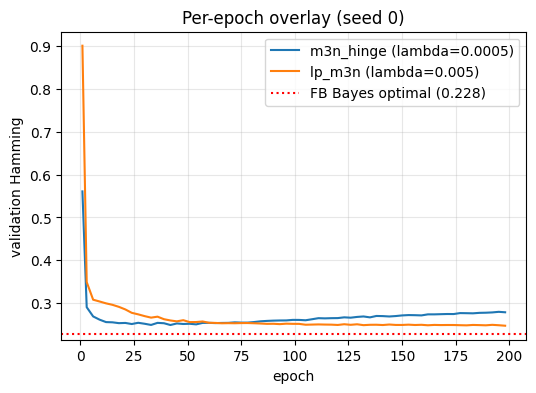

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

for loss in LOSSES:
    h_path = out_dir(loss, BEST_LAMBDA[loss], SEEDS[0]) / 'history.json'
    history = json.loads(h_path.read_text())
    val_h = [m['hamming'] for m in history['val_metrics']]
    ax.plot(history['epoch'], val_h, label=f"{loss} (lambda={BEST_LAMBDA[loss]:g})")

ax.axhline(fb_hamming, color='red', linestyle=':',
           label=f'FB Bayes optimal ({fb_hamming:.3f})')
ax.set_xlabel('epoch')
ax.set_ylabel('validation Hamming')
ax.set_title(f'Per-epoch overlay (seed {SEEDS[0]})')
ax.legend()
ax.grid(True, alpha=0.3)

fig.savefig(THESIS_FIG / 'per_epoch.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. Learned pairwise weights (best lambda)

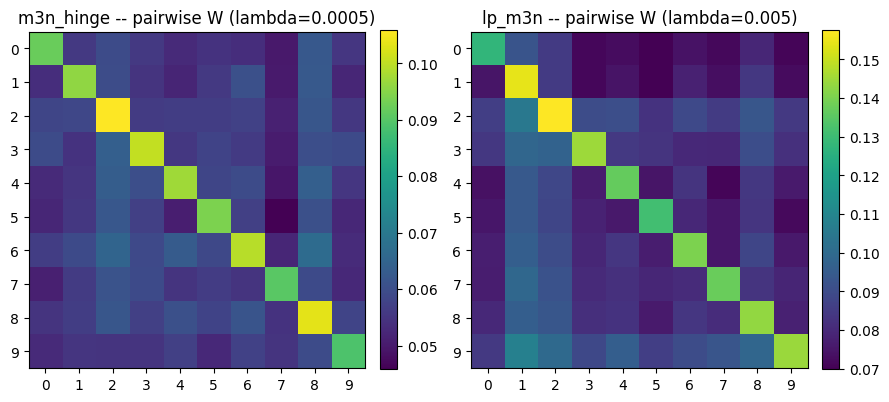

In [10]:
pairwise = {}
for loss in LOSSES:
    sd = torch.load(out_dir(loss, BEST_LAMBDA[loss], SEEDS[0]) / 'model.pt', weights_only=True)
    pairwise[loss] = sd['pairwise'].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, loss in zip(axes, LOSSES):
    W = pairwise[loss]
    im = ax.imshow(W, cmap='viridis', vmin=W.min(), vmax=W.max())
    ax.set_title(f'{loss} -- pairwise W (lambda={BEST_LAMBDA[loss]:g})')
    ax.set_xticks(range(W.shape[1]))
    ax.set_yticks(range(W.shape[0]))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(THESIS_FIG / 'learned_weights.png', bbox_inches='tight', dpi=150)
plt.show()

## 10. Test predictions for diagnostics

Load the best-lambda models and run Viterbi on the test set once. Shared by per-position Hamming and confusion-matrix plots.

In [11]:
test_X, test_Y = build_datasets(BASE_CONFIGS['m3n_hinge'].data, base_dir=REPO_ROOT)['test']

@torch.no_grad()
def predict_test(loss, wd, seed, chunk_size=64):
    cfg = BASE_CONFIGS[loss]
    model, edges = build_model(cfg.architecture, base_dir=REPO_ROOT)
    sd = torch.load(out_dir(loss, wd, seed) / 'model.pt', weights_only=True)
    model.load_state_dict(sd)
    model = model.to(DEVICE).eval()
    edges = edges.to(DEVICE)
    preds = []
    for i in range(0, test_X.shape[0], chunk_size):
        unary = model.unary(test_X[i:i + chunk_size].to(DEVICE))
        preds.append(viterbi_decode(unary, model.pairwise).cpu())
    return torch.cat(preds, dim=0)

predictions = {loss: predict_test(loss, BEST_LAMBDA[loss], SEEDS[0]) for loss in LOSSES}

## 11. Confusion matrix

Row-normalised: rows = true hidden state, cols = predicted hidden state.

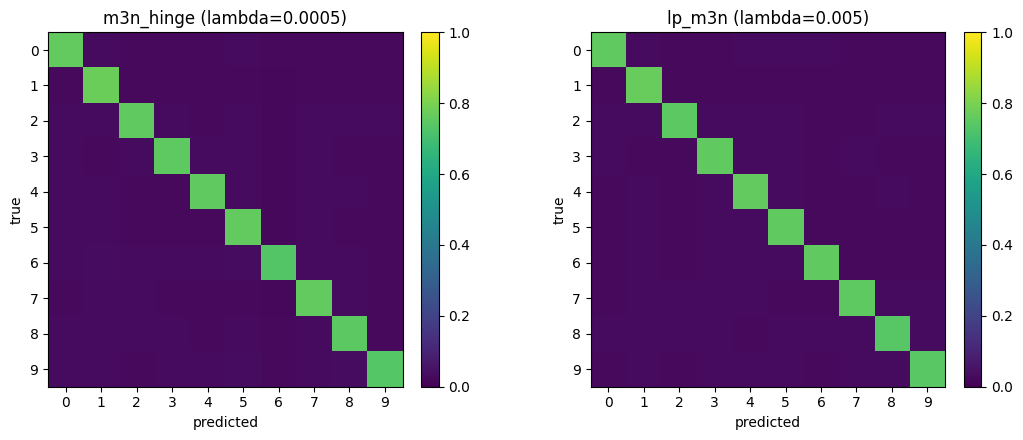

In [13]:
def confusion(true, pred, K):
    cm = np.zeros((K, K), dtype=np.int64)
    np.add.at(cm, (true.flatten().numpy(), pred.flatten().numpy()), 1)
    return cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, loss in zip(axes, LOSSES):
    cm = confusion(test_Y, predictions[loss], K)
    im = ax.imshow(cm, cmap='viridis', vmin=0.0, vmax=1.0)
    ax.set_title(f'{loss} (lambda={BEST_LAMBDA[loss]:g})')
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.set_xticks(range(K))
    ax.set_yticks(range(K))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(THESIS_FIG / 'confusion.png', bbox_inches='tight', dpi=150)
plt.show()